In [4]:
import os
import matplotlib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
import logging

# GLOBAL CONSTANTS
PATH_TO_FIGURES = "./fig/"
FIGSIZE = (9, 6)
LEGEND_FONTSIZE = 18
LABEL_FONTSIZE = 28
hatches = ['xx', '\\\\', '//', '--', '++', '||', 'o', 'O', '.', '*']
width = 0.35  # the width of the bars
line_width = 3.5
# colors = ['#7F449B', '#009D72', '#E5A023']
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
system = ["GAE", "vSoC", "Anbox", "Redroid", "MCon"]
font = {'family': 'Arial',
        'weight': 'normal',
        'size': LABEL_FONTSIZE}

# envsetup
plt.rc('font', **font)
plt.rcParams.update({'legend.handlelength': 1.3, 'legend.borderpad': 0.25,
                     "legend.labelspacing": 0.25, "legend.handletextpad": 0.5})
plt.rcParams['hatch.linewidth'] = line_width
pd.set_option("display.max_colwidth", 5000)
pd.set_option("display.max_columns", 10000)
pd.set_option("display.max_rows", 100)
os.makedirs(PATH_TO_FIGURES, exist_ok=True)
warnings.filterwarnings('ignore')

# refresh the fonts just installed
matplotlib.font_manager._load_fontmanager(try_read_cache=False)





In [5]:
# Hardcoded final plotting data (no file read, no post-processing)
gae = [13.22, 13.29, 13.06175, 14.534625, 23.262933333333326, 37.977405582636834, 60.13922727190264]
vsoc = [24.111, 19.1025, 16.8365, 16.65775, 18.16125, 27.069149999999997, 35.10126379508982]
anbox = [55.873, 66.74950000000001, 78.8755, 82.20675, 90.41874999999999, 112.27759375, 161.15114516129032]
redroid = [15.998, 16.548000000000002, 19.424, 30.8933625, 34.9695625, 40.25515, 116.95991093750001]
mcon = [1.034, 1.125, 1.214, 1.336, 1.3816875, 1.6966875, 2.056671875]
gae_max = 64
vsoc_max = 64
anbox_max = 64
redroid_max = 64
mcon_max = 64
x = np.log2([1, 2, 4, 8, 16, 32, 64])
y_gae = gae
y_vsoc = vsoc
y_anbox = anbox
y_redroid = redroid
y_mcon = mcon

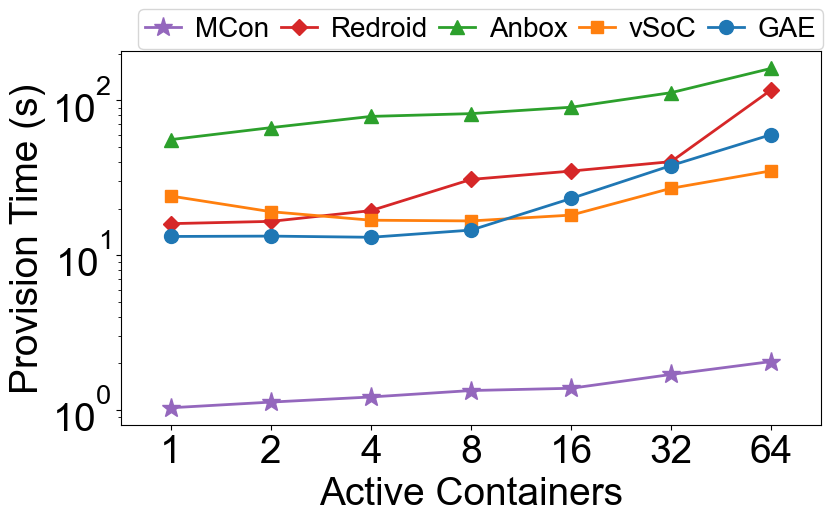

In [7]:

# =========================
# 画图
# =========================
plt.figure(figsize=FIGSIZE)

plt.xlim(-0.5, 6.5)




plt.plot(x, y_mcon, marker="*",markersize=14, linewidth=2, label="MCon", color=colors[4])
plt.plot(x, y_redroid, marker="D", markersize=8, linewidth=2, label="Redroid", color=colors[3])
plt.plot(x, y_anbox, marker="^",markersize=10, linewidth=2, label="Anbox", color=colors[2])
plt.plot(x, y_vsoc, marker="s", markersize=8, linewidth=2, label="vSoC", color=colors[1])
plt.plot(x, y_gae, marker="o", markersize=10,linewidth=2, label="GAE", color=colors[0])


# =========================
# 坐标轴设置
# =========================
x_ticks = np.array([1, 2, 4, 8, 16, 32, 64])
x_log = np.log2(x_ticks)

plt.xticks(x_log, x_ticks, fontsize=LABEL_FONTSIZE)
plt.xlabel("Active Containers", fontsize=LABEL_FONTSIZE)
plt.ylabel("Provision Time (s)", fontsize=LABEL_FONTSIZE)

plt.yscale("log", base=10)

# plt.title("Container Startup Time vs. Number of Containers")
# plt.grid(True, linestyle="--", alpha=0.5)
# plt.legend()
plt.legend(
    loc="upper left",          # 左上角对齐锚点
    ncol=5,                    # ✅ 两列排放
    # frameon=True,             # 显示边框
    bbox_to_anchor=(0.005, 1.15),  # ✅ 控制与图边框的距离（x, y）SS
    fontsize=20,
    # borderpad=0.6,            # 图例内容与边框的内边距
    # labelspacing=0.2,         # 每一项之间的竖直间距
    columnspacing=0.4,        # 两列之间的水平间距
    # handletextpad=0.6         # marker 与文字之间的间距
)
plt.tight_layout()

plt.savefig(PATH_TO_FIGURES + "container_provision.pdf", format="pdf", bbox_inches="tight", pad_inches=0)
plt.show()